# Cómo usar este notebook

> Este notebook está pensado como un **recetario de código**.

- No es obligatorio que "corras" cada celda aquí mismo.
- En cada sección verás bloques de código listos para **copiar y pegar** en tu propio entorno (VS Code, Jupyter, Colab, etc.).
- Si lo prefieres, también puedes ejecutarlos directamente desde este notebook para ver los resultados al instante.

La idea es que tengas todos los ejemplos organizados en un solo lugar, y que puedas reutilizar el código fácilmente en tus propios proyectos.

## 📦 Celda 1: Importar Librerías
Primero importamos las librerías necesarias.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Configuración para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print("✅ Librerías importadas correctamente")

: 

---
## 🏠 Celda 2: Regresión Lineal — La Red Más Simple
La regresión lineal es literalmente una neurona sin función de activación: `y = wx + b`

📊 Datos de casas:
  30 m² → $128k
  50 m² → $176k
  70 m² → $227k
  80 m² → $252k
  100 m² → $289k
  120 m² → $348k
  150 m² → $447k


c:\Users\RX971WG\AppData\Local\miniconda3\envs\AURORA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


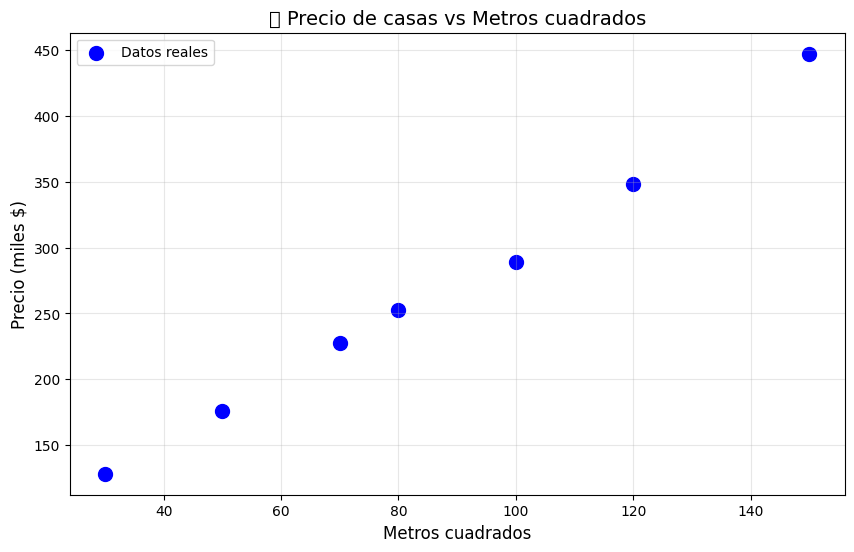

In [4]:
# Datos: metros cuadrados -> precio de casa (en miles)
# Generamos datos sintéticos: precio = 2.5 * m2 + 50 + ruido
metros_cuadrados = torch.tensor([[30.], [50.], [70.], [80.], [100.], [120.], [150.]])
precios_reales = 2.5 * metros_cuadrados + 50 + torch.randn(7, 1) * 10

print("📊 Datos de casas:")
print("="*40)
for m2, precio in zip(metros_cuadrados, precios_reales):
    print(f"  {m2.item():.0f} m² → ${precio.item():.0f}k")

# Visualización
plt.figure(figsize=(10, 6))
plt.scatter(metros_cuadrados.numpy(), precios_reales.numpy(), s=100, c='blue', label='Datos reales')
plt.xlabel('Metros cuadrados', fontsize=12)
plt.ylabel('Precio (miles $)', fontsize=12)
plt.title('🏠 Precio de casas vs Metros cuadrados', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Creamos el modelo más simple: `nn.Linear(1, 1)`

In [5]:
# El modelo MÁS SIMPLE: 1 entrada → 1 salida (sin activación)
modelo_lineal = nn.Linear(1, 1)

print("🔍 Parámetros del modelo (antes de entrenar):")
print(f"  w (peso) = {modelo_lineal.weight.item():.4f}")
print(f"  b (bias) = {modelo_lineal.bias.item():.4f}")
print(f"\n📐 Fórmula: ŷ = {modelo_lineal.weight.item():.4f} × x + {modelo_lineal.bias.item():.4f}")

# Predicción con parámetros aleatorios
prediccion_inicial = modelo_lineal(metros_cuadrados)
print(f"\n⚠️ Predicción inicial para 80m²: ${prediccion_inicial[3].item():.2f}k (¡muy lejos!)")

🔍 Parámetros del modelo (antes de entrenar):
  w (peso) = 0.7709
  b (bias) = 0.1478

📐 Fórmula: ŷ = 0.7709 × x + 0.1478

⚠️ Predicción inicial para 80m²: $61.82k (¡muy lejos!)


---
## ⚖️ Celda 3: Pesos y Bias — Los Parámetros Aprendibles

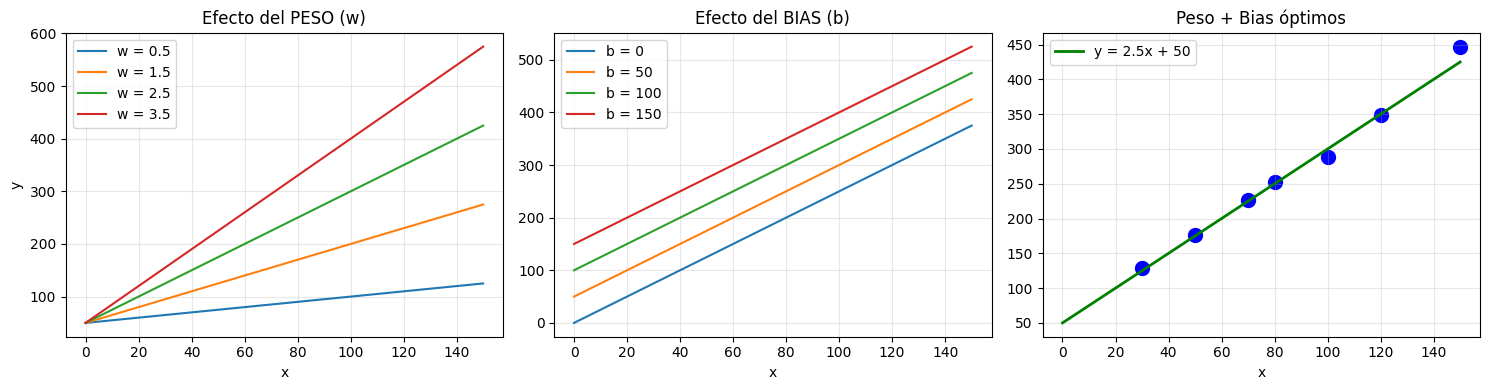

💡 El peso controla la PENDIENTE, el bias controla el PUNTO DE CORTE


In [6]:
# Visualizamos cómo diferentes pesos y bias cambian la línea
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(0, 150, 100)

# Diferentes pesos (pendientes)
axes[0].set_title('Efecto del PESO (w)', fontsize=12)
for w in [0.5, 1.5, 2.5, 3.5]:
    axes[0].plot(x, w * x + 50, label=f'w = {w}')
axes[0].legend()
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

# Diferentes bias (interceptos)
axes[1].set_title('Efecto del BIAS (b)', fontsize=12)
for b in [0, 50, 100, 150]:
    axes[1].plot(x, 2.5 * x + b, label=f'b = {b}')
axes[1].legend()
axes[1].set_xlabel('x')
axes[1].grid(True, alpha=0.3)

# Combinación ideal
axes[2].set_title('Peso + Bias óptimos', fontsize=12)
axes[2].scatter(metros_cuadrados.numpy(), precios_reales.numpy(), s=100, c='blue')
axes[2].plot(x, 2.5 * x + 50, 'g-', linewidth=2, label='y = 2.5x + 50')
axes[2].legend()
axes[2].set_xlabel('x')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 El peso controla la PENDIENTE, el bias controla el PUNTO DE CORTE")

---
## 📈 Celda 4: Funciones de Pérdida (Loss Functions)
Miden qué tan "mal" están nuestras predicciones.

In [7]:
# Predicciones del modelo (antes de entrenar)
predicciones = modelo_lineal(metros_cuadrados)

# MSE Loss (Mean Squared Error) - para regresión
mse_loss = nn.MSELoss()
loss_valor = mse_loss(predicciones, precios_reales)

print("📉 FUNCIONES DE PÉRDIDA")
print("="*50)
print("\n1️⃣ MSE (Mean Squared Error) - Para regresión:")
print(f"   Fórmula: (1/n) × Σ(ŷ - y)²")
print(f"   Valor actual: {loss_valor.item():.2f}")

# Visualización del error
print("\n📊 Errores por cada casa:")
errores = predicciones - precios_reales
for i, (pred, real, err) in enumerate(zip(predicciones, precios_reales, errores)):
    print(f"   Casa {i+1}: Predicho ${pred.item():.1f}k, Real ${real.item():.1f}k → Error: {err.item():.1f}")

📉 FUNCIONES DE PÉRDIDA

1️⃣ MSE (Mean Squared Error) - Para regresión:
   Fórmula: (1/n) × Σ(ŷ - y)²
   Valor actual: 45150.11

📊 Errores por cada casa:
   Casa 1: Predicho $23.3k, Real $128.4k → Error: -105.1
   Casa 2: Predicho $38.7k, Real $176.3k → Error: -137.6
   Casa 3: Predicho $54.1k, Real $227.3k → Error: -173.2
   Casa 4: Predicho $61.8k, Real $252.3k → Error: -190.5
   Casa 5: Predicho $77.2k, Real $288.8k → Error: -211.5
   Casa 6: Predicho $92.7k, Real $348.1k → Error: -255.5
   Casa 7: Predicho $115.8k, Real $447.1k → Error: -331.3


In [8]:
# CrossEntropyLoss - para clasificación
print("\n2️⃣ CrossEntropyLoss - Para clasificación:")

# Simulamos logits para 3 clases y 4 ejemplos
logits = torch.tensor([[2.0, 1.0, 0.1],   # Modelo confiado en clase 0
                       [0.5, 2.5, 0.3],   # Modelo confiado en clase 1
                       [0.1, 0.2, 3.0],   # Modelo confiado en clase 2
                       [1.0, 1.0, 1.0]])  # Modelo confundido

etiquetas = torch.tensor([0, 1, 2, 0])  # Clases verdaderas

ce_loss = nn.CrossEntropyLoss(reduction='none')  # Ver loss individual
losses = ce_loss(logits, etiquetas)

print(f"   Fórmula: -log(probabilidad de la clase correcta)")
print("\n   Ejemplo por ejemplo:")
for i, (logit, label, loss) in enumerate(zip(logits, etiquetas, losses)):
    probs = torch.softmax(logit, dim=0)
    print(f"   Ej {i+1}: Probs {probs.numpy().round(2)} | Clase real: {label.item()} | Loss: {loss.item():.3f}")

print(f"\n   📌 Nota: Loss BAJO = modelo CONFIADO en la clase CORRECTA")


2️⃣ CrossEntropyLoss - Para clasificación:
   Fórmula: -log(probabilidad de la clase correcta)

   Ejemplo por ejemplo:
   Ej 1: Probs [0.66 0.24 0.1 ] | Clase real: 0 | Loss: 0.417
   Ej 2: Probs [0.11 0.8  0.09] | Clase real: 1 | Loss: 0.220
   Ej 3: Probs [0.05 0.05 0.9 ] | Clase real: 2 | Loss: 0.110
   Ej 4: Probs [0.33 0.33 0.33] | Clase real: 0 | Loss: 1.099

   📌 Nota: Loss BAJO = modelo CONFIADO en la clase CORRECTA


---
## 🔄 Celda 5: Backpropagation y Gradientes
La magia de PyTorch: calcula gradientes automáticamente.

In [9]:
# Ejemplo simple de autograd
print("🎯 AUTOGRAD: Diferenciación Automática")
print("="*50)

# Creamos tensores con requires_grad=True
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# Forward pass
y = w * x + b  # y = 3*2 + 1 = 7
print(f"\n1️⃣ Forward: y = w*x + b = {w.item()}*{x.item()} + {b.item()} = {y.item()}")

# Backward pass (calcula gradientes)
y.backward()

print(f"\n2️⃣ Backward (gradientes):")
print(f"   ∂y/∂w = x = {w.grad.item()}  (porque y = w*x + b)")
print(f"   ∂y/∂x = w = {x.grad.item()}  (porque y = w*x + b)")
print(f"   ∂y/∂b = 1 = {b.grad.item()}  (porque y = w*x + b)")

print("\n💡 PyTorch calculó automáticamente ∂y/∂(cada variable)!")

🎯 AUTOGRAD: Diferenciación Automática

1️⃣ Forward: y = w*x + b = 3.0*2.0 + 1.0 = 7.0

2️⃣ Backward (gradientes):
   ∂y/∂w = x = 2.0  (porque y = w*x + b)
   ∂y/∂x = w = 3.0  (porque y = w*x + b)
   ∂y/∂b = 1 = 1.0  (porque y = w*x + b)

💡 PyTorch calculó automáticamente ∂y/∂(cada variable)!


In [10]:
# Gradientes en nuestro modelo de regresión
print("\n📐 Gradientes en el modelo de regresión:")
print("="*50)

# Reiniciamos el modelo
modelo = nn.Linear(1, 1)
criterion = nn.MSELoss()

# Forward pass
predicciones = modelo(metros_cuadrados)
loss = criterion(predicciones, precios_reales)

print(f"Peso antes: {modelo.weight.item():.4f}")
print(f"Bias antes: {modelo.bias.item():.4f}")
print(f"Loss: {loss.item():.2f}")

# Backward pass
loss.backward()

print(f"\n📉 Gradientes calculados:")
print(f"   ∂Loss/∂peso = {modelo.weight.grad.item():.4f}")
print(f"   ∂Loss/∂bias = {modelo.bias.grad.item():.4f}")
print(f"\n   → El gradiente indica EN QUÉ DIRECCIÓN mover cada parámetro para reducir el loss")


📐 Gradientes en el modelo de regresión:
Peso antes: -0.4668
Bias antes: 0.2549
Loss: 107687.30

📉 Gradientes calculados:
   ∂Loss/∂peso = -61452.5898
   ∂Loss/∂bias = -613.3180

   → El gradiente indica EN QUÉ DIRECCIÓN mover cada parámetro para reducir el loss


---
## 🚀 Celda 6: Optimizadores y Learning Rate
El optimizador usa los gradientes para actualizar los pesos.

🎚️ EFECTO DEL LEARNING RATE
LR = 0.0001: Loss inicial = 107540.57, Loss final = 405.46
LR = 0.001: Loss inicial = 103744.56, Loss final = nan
LR = 0.01: Loss inicial = 128902.21, Loss final = nan


c:\Users\RX971WG\AppData\Local\miniconda3\envs\AURORA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127898 (\N{LEVEL SLIDER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


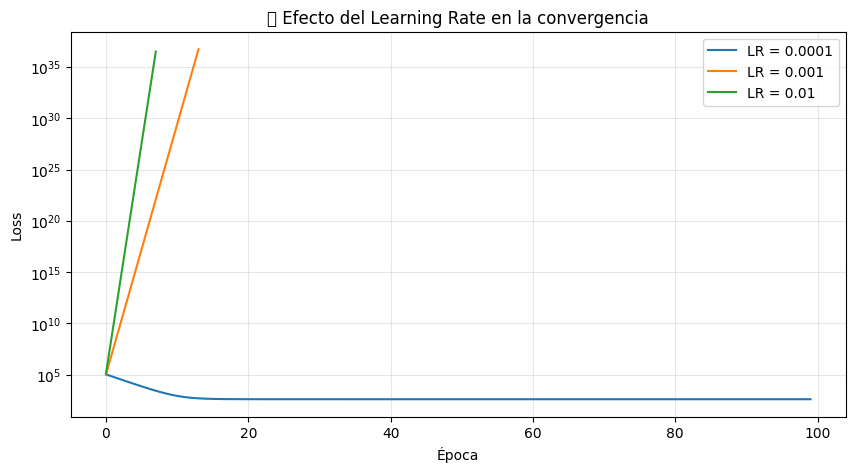


💡 Un LR muy bajo converge lento, un LR muy alto puede no converger


In [11]:
# Comparación de Learning Rates
print("🎚️ EFECTO DEL LEARNING RATE")
print("="*50)

learning_rates = [0.0001, 0.001, 0.01]
resultados = {}

for lr in learning_rates:
    # Modelo nuevo para cada experimento
    modelo = nn.Linear(1, 1)
    optimizer = torch.optim.SGD(modelo.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    losses = []
    for epoch in range(100):
        optimizer.zero_grad()
        pred = modelo(metros_cuadrados)
        loss = criterion(pred, precios_reales)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    resultados[lr] = losses
    print(f"LR = {lr}: Loss inicial = {losses[0]:.2f}, Loss final = {losses[-1]:.2f}")

# Visualización
plt.figure(figsize=(10, 5))
for lr, losses in resultados.items():
    plt.plot(losses, label=f'LR = {lr}')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('🎚️ Efecto del Learning Rate en la convergencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print("\n💡 Un LR muy bajo converge lento, un LR muy alto puede no converger")

---
## 🔮 Celda 7: El Ejercicio del Círculo — ¿Por Qué Necesitamos Capas Ocultas?
Este es el ejemplo más importante: datos que NO se pueden separar con una línea.

### 🎮 Recurso Interactivo Recomendado
Antes de ver el código, te recomiendo explorar este concepto visualmente con **TensorFlow Playground**:

👉 **[Abrir TensorFlow Playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.12345&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)**

<iframe src="https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.12345&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false" width="100%" height="500" frameborder="0"></iframe>

> 💡 **Ejercicio**: Prueba con el dataset "circle" (ya seleccionado en el enlace) y observa cómo:
> - Sin capas ocultas → ¡No puede separar los puntos!
> - Con 1+ capas ocultas → ¡Aprende la frontera circular!

In [12]:
# Generamos datos en forma de círculo
from sklearn.datasets import make_circles

# Puntos azules en el centro, rojos en el anillo exterior
X, y = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# Visualización
plt.figure(figsize=(8, 8))
plt.scatter(X[y.squeeze()==0, 0], X[y.squeeze()==0, 1], c='blue', s=50, label='Clase 0 (centro)')
plt.scatter(X[y.squeeze()==1, 0], X[y.squeeze()==1, 1], c='red', s=50, label='Clase 1 (anillo)')
plt.title('🎯 El Problema del Círculo\n¿Puedes dibujar UNA LÍNEA que los separe?', fontsize=14)
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

print("❓ PREGUNTA: ¿Es posible separar azules de rojos con una línea recta?")
print("   RESPUESTA: ¡NO! Necesitamos una frontera CURVA.")

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Modelo LINEAL (sin capa oculta) - FALLARÁ
print("❌ INTENTO 1: Modelo Lineal (sin capas ocultas)")
print("="*50)

modelo_lineal = nn.Sequential(
    nn.Linear(2, 1),  # Solo una capa: 2 entradas → 1 salida
    nn.Sigmoid()
)

optimizer = torch.optim.Adam(modelo_lineal.parameters(), lr=0.1)
criterion = nn.BCELoss()

losses_lineal = []
for epoch in range(500):
    optimizer.zero_grad()
    pred = modelo_lineal(X)
    loss = criterion(pred, y)
    loss.backward()
    optimizer.step()
    losses_lineal.append(loss.item())

# Accuracy
with torch.no_grad():
    pred_labels = (modelo_lineal(X) > 0.5).float()
    accuracy_lineal = (pred_labels == y).float().mean()

print(f"Loss final: {losses_lineal[-1]:.4f}")
print(f"Accuracy: {accuracy_lineal.item()*100:.1f}%")
print(f"\n⚠️ ¡Solo ~50% de accuracy! (igual que adivinar al azar)")

In [ ]:
# Modelo con 3 NEURONAS OCULTAS - ¡FUNCIONARÁ!
print("\n✅ INTENTO 2: Modelo con 3 Neuronas Ocultas")
print("="*50)

modelo_oculto = nn.Sequential(
    nn.Linear(2, 3),   # 2 entradas → 3 ocultas
    nn.ReLU(),         # Activación no-lineal
    nn.Linear(3, 1),   # 3 ocultas → 1 salida
    nn.Sigmoid()
)

optimizer = torch.optim.Adam(modelo_oculto.parameters(), lr=0.1)

losses_oculto = []
for epoch in range(500):
    optimizer.zero_grad()
    pred = modelo_oculto(X)
    loss = criterion(pred, y)
    loss.backward()
    optimizer.step()
    losses_oculto.append(loss.item())

# Accuracy
with torch.no_grad():
    pred_labels = (modelo_oculto(X) > 0.5).float()
    accuracy_oculto = (pred_labels == y).float().mean()

print(f"Loss final: {losses_oculto[-1]:.4f}")
print(f"Accuracy: {accuracy_oculto.item()*100:.1f}%")
print(f"\n🎉 ¡Con solo 3 neuronas ocultas logramos ~100%!")

In [ ]:
# Visualización de la frontera de decisión
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Crear grid para visualizar
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

# Plot 1: Datos originales
axes[0].scatter(X[y.squeeze()==0, 0], X[y.squeeze()==0, 1], c='blue', s=30)
axes[0].scatter(X[y.squeeze()==1, 0], X[y.squeeze()==1, 1], c='red', s=30)
axes[0].set_title('Datos originales', fontsize=12)
axes[0].axis('equal')

# Plot 2: Frontera del modelo lineal
with torch.no_grad():
    Z_lineal = modelo_lineal(grid).reshape(xx.shape)
axes[1].contourf(xx, yy, Z_lineal, levels=20, cmap='RdBu', alpha=0.6)
axes[1].scatter(X[y.squeeze()==0, 0], X[y.squeeze()==0, 1], c='blue', s=30, edgecolor='white')
axes[1].scatter(X[y.squeeze()==1, 0], X[y.squeeze()==1, 1], c='red', s=30, edgecolor='white')
axes[1].set_title(f'❌ Modelo Lineal\nAcc: {accuracy_lineal.item()*100:.0f}%', fontsize=12)
axes[1].axis('equal')

# Plot 3: Frontera del modelo con capa oculta
with torch.no_grad():
    Z_oculto = modelo_oculto(grid).reshape(xx.shape)
axes[2].contourf(xx, yy, Z_oculto, levels=20, cmap='RdBu', alpha=0.6)
axes[2].scatter(X[y.squeeze()==0, 0], X[y.squeeze()==0, 1], c='blue', s=30, edgecolor='white')
axes[2].scatter(X[y.squeeze()==1, 0], X[y.squeeze()==1, 1], c='red', s=30, edgecolor='white')
axes[2].set_title(f'✅ 3 Neuronas Ocultas\nAcc: {accuracy_oculto.item()*100:.0f}%', fontsize=12)
axes[2].axis('equal')

plt.tight_layout()
plt.show()

print("💡 MORALEJA: Las capas ocultas permiten aprender fronteras NO LINEALES")

---
## 🎲 Celda 8: Regularización — Evitando el Overfitting

In [ ]:
# Demostración de Dropout
print("🎲 DROPOUT: Apagando neuronas aleatoriamente")
print("="*50)

dropout = nn.Dropout(p=0.5)  # 50% de probabilidad de "apagar"

# Entrada de ejemplo
entrada = torch.ones(1, 10)  # 10 neuronas, todas activas

print(f"\nEntrada original: {entrada.numpy()}")

# Durante entrenamiento (mode=train)
dropout.train()
for i in range(3):
    salida = dropout(entrada)
    print(f"Salida {i+1} (training): {salida.numpy()}  ← Algunas apagadas (0), otras escaladas (×2)")

# Durante evaluación (mode=eval)
dropout.eval()
salida_eval = dropout(entrada)
print(f"\nSalida (eval):     {salida_eval.numpy()}  ← Todas activas (sin dropout)")

print("\n💡 Dropout SOLO se aplica durante entrenamiento, no en evaluación/inferencia")

---
## ⚡ Celda 9: Funciones de Activación

In [ ]:
# Visualización de funciones de activación
x = torch.linspace(-5, 5, 100)

activations = {
    'ReLU': torch.relu(x),
    'Sigmoid': torch.sigmoid(x),
    'Tanh': torch.tanh(x),
    'LeakyReLU': nn.functional.leaky_relu(x, 0.1)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colors = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444']

for i, (name, y) in enumerate(activations.items()):
    axes[i].plot(x.numpy(), y.numpy(), color=colors[i], linewidth=3)
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].set_title(name, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('f(x)')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(-5, 5)

plt.suptitle('⚡ Funciones de Activación', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Cuándo usar cada una:")
print("   • ReLU: Default para capas ocultas (rápida, eficiente)")
print("   • Sigmoid: Capa final para clasificación binaria (0-1)")
print("   • Tanh: Alternativa a Sigmoid (-1 a 1)")
print("   • LeakyReLU: Evita 'neuronas muertas' del ReLU")

### 🎯 Softmax en la última capa (multiclase)
- Convierte logits en probabilidades y fuerza que Σ probs = 1.
- Úsala cuando hay más de 2 clases; para binario, Sigmoid basta.
- Ejemplo rápido: logits [2, 1, 0] → softmax ≈ [0.66, 0.24, 0.10] (se suman a 1).
- En PyTorch: pasa los logits sin softmax a `CrossEntropyLoss` (la aplica de forma estable).
- Abajo tienes un slider interactivo para mover logits y ver cómo cambian las probabilidades (igual de didáctico que el de Sigmoid).

In [ ]:
# Softmax para clasificación multiclase (estático + slider interactivo)
print("\n🎯 SOFTMAX: Convirtiendo logits en probabilidades")
print("="*50)

import ipywidgets as widgets
from IPython.display import display

# Ejemplo fijo
logits = torch.tensor([2.0, 1.0, 0.5, -1.0])  # "Puntuaciones" crudas del modelo
probabilidades = torch.softmax(logits, dim=0)

print(f"\nLogits (salida cruda):  {logits.numpy()}")
print(f"Probabilidades:         {probabilidades.numpy().round(3)}")
print(f"Suma de probabilidades: {probabilidades.sum().item():.3f} (siempre = 1)")

# Visualización estática
clases = ['Gato', 'Perro', 'Pájaro', 'Pez']
plt.figure(figsize=(10, 4))
plt.bar(clases, probabilidades.numpy(), color=['#3b82f6', '#10b981', '#f59e0b', '#ef4444'])
plt.ylabel('Probabilidad')
plt.title('🎯 Softmax: De logits a probabilidades')
for i, (c, p) in enumerate(zip(clases, probabilidades)):
    plt.text(i, p + 0.02, f'{p.item():.1%}', ha='center', fontweight='bold')
plt.ylim(0, 0.7)
plt.show()

print("\n🤝 Consejo: pasa logits (sin softmax) a nn.CrossEntropyLoss; aplica softmax interna de forma estable.")

# --- Slider interactivo (3 clases) ---
print("\n🧭 Mueve los logits para ver cómo cambian las probabilidades:")

def softmax_interactivo(logit_a=2.0, logit_b=1.0, logit_c=0.0):
    logits_local = torch.tensor([logit_a, logit_b, logit_c])
    probs_local = torch.softmax(logits_local, dim=0)
    fig, ax = plt.subplots(figsize=(8, 4))
    clases_local = ['Clase 0', 'Clase 1', 'Clase 2']
    bars = ax.bar(clases_local, probs_local.numpy(), color=['#3b82f6', '#10b981', '#f59e0b'])
    for bar, p in zip(bars, probs_local):
        ax.text(bar.get_x() + bar.get_width()/2, p + 0.02, f'{p.item():.1%}', ha='center', fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probabilidad')
    ax.set_title('Softmax interactivo (suma siempre 1)')
    ax.grid(True, axis='y', alpha=0.2)
    plt.show()
    print(f"Logits: {logits_local.numpy().round(2)}")
    print(f"Probabilidades: {probs_local.numpy().round(3)} → suma = {probs_local.sum().item():.3f}")

slider_a = widgets.FloatSlider(value=2.0, min=-4.0, max=4.0, step=0.1, description='Logit 0')
slider_b = widgets.FloatSlider(value=1.0, min=-4.0, max=4.0, step=0.1, description='Logit 1')
slider_c = widgets.FloatSlider(value=0.0, min=-4.0, max=4.0, step=0.1, description='Logit 2')
ui = widgets.VBox([slider_a, slider_b, slider_c])

out = widgets.interactive_output(softmax_interactivo, {'logit_a': slider_a, 'logit_b': slider_b, 'logit_c': slider_c})
display(ui, out)

print("\n🙌 Gracias por explorar softmax con el slider interactivo.")

In [ ]:
# 🧠 Red Neuronal Interactiva: De Logits a Probabilidades
# Visualiza cómo cambia la transformación según el número de clases

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

print("🧠 RED NEURONAL: LOGITS → PROBABILIDADES")
print("="*60)
print("Ajusta el número de clases y los logits para ver la transformación")
print()

# Función para crear la visualización
def visualizar_red(num_clases, *logit_values):
    clear_output(wait=True)
    
    # Mostrar instrucciones
    print("🧠 RED NEURONAL: LOGITS → PROBABILIDADES")
    print("="*60)
    
    # Obtener logits activos según número de clases
    logits = torch.tensor([logit_values[i] for i in range(num_clases)])
    
    # Determinar tipo de clasificación y aplicar transformación
    if num_clases == 1:
        # Clasificación binaria con 1 salida → Sigmoid
        probs = torch.sigmoid(logits)
        tipo = "BINARIA (1 salida)"
        transformacion = "Sigmoid"
        formula = f"σ(z) = 1/(1+e^(-z))"
        clases = ["Clase 1 (prob)", "Clase 0 (1-prob)"]
        probs_display = torch.tensor([probs[0], 1 - probs[0]])
        colores = ['#3b82f6', '#94a3b8']
    elif num_clases == 2:
        # Binaria con 2 salidas → Softmax (equivalente a sigmoid en este caso)
        probs = torch.softmax(logits, dim=0)
        probs_display = probs
        tipo = "BINARIA (2 salidas)"
        transformacion = "Softmax"
        formula = "softmax(z)ᵢ = exp(zᵢ) / Σexp(zⱼ)"
        clases = ["Clase 0", "Clase 1"]
        colores = ['#3b82f6', '#10b981']
    else:
        # Multiclase → Softmax
        probs = torch.softmax(logits, dim=0)
        probs_display = probs
        tipo = f"MULTICLASE ({num_clases} clases)"
        transformacion = "Softmax"
        formula = "softmax(z)ᵢ = exp(zᵢ) / Σexp(zⱼ)"
        clases = [f"Clase {i}" for i in range(num_clases)]
        colores = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6'][:num_clases]
    
    # Crear figura con 3 paneles
    fig = plt.figure(figsize=(14, 6))
    
    # Panel 1: Diagrama de la red neuronal
    ax1 = fig.add_subplot(131)
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.axis('off')
    ax1.set_title('🏗️ Arquitectura', fontsize=12, fontweight='bold')
    
    # Dibujar neuronas de entrada (2 features)
    entrada_y = [6, 4]
    for i, y in enumerate(entrada_y):
        circle = plt.Circle((2, y), 0.4, color='#64748b', ec='white', linewidth=2)
        ax1.add_patch(circle)
        ax1.text(2, y, f'x{i}', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # Capa oculta (3 neuronas)
    oculta_y = [7, 5, 3]
    for i, y in enumerate(oculta_y):
        circle = plt.Circle((5, y), 0.4, color='#6366f1', ec='white', linewidth=2)
        ax1.add_patch(circle)
        ax1.text(5, y, f'h{i}', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
        # Conexiones entrada → oculta
        for ey in entrada_y:
            ax1.plot([2.4, 4.6], [ey, y], 'gray', alpha=0.3, linewidth=0.5)
    
    # Neuronas de salida (logits)
    salida_y_positions = np.linspace(8, 2, num_clases) if num_clases > 1 else [5]
    for i, y in enumerate(salida_y_positions):
        circle = plt.Circle((8, y), 0.4, color=colores[i], ec='white', linewidth=2)
        ax1.add_patch(circle)
        ax1.text(8, y, f'z{i}', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
        # Conexiones oculta → salida
        for hy in oculta_y:
            ax1.plot([5.4, 7.6], [hy, y], 'gray', alpha=0.3, linewidth=0.5)
    
    # Etiquetas
    ax1.text(2, 8.5, 'Entrada', ha='center', fontsize=10, color='#64748b')
    ax1.text(5, 8.5, 'Oculta', ha='center', fontsize=10, color='#6366f1')
    ax1.text(8, 8.5, 'Salida\n(logits)', ha='center', fontsize=10, color='#22c55e')
    
    # Panel 2: Logits y Transformación
    ax2 = fig.add_subplot(132)
    ax2.axis('off')
    ax2.set_xlim(0, 10)
    ax2.set_ylim(0, 10)
    ax2.set_title(f'🔄 {transformacion}', fontsize=12, fontweight='bold')
    
    # Mostrar tipo de clasificación
    ax2.text(5, 9.5, f"Tipo: {tipo}", ha='center', fontsize=11, fontweight='bold', color='#c4b5fd')
    
    # Mostrar logits
    ax2.text(5, 8.5, "LOGITS (salida cruda)", ha='center', fontsize=10, color='#fbbf24')
    logit_str = "[" + ", ".join([f"{l:.1f}" for l in logits.numpy()]) + "]"
    ax2.text(5, 7.8, logit_str, ha='center', fontsize=12, fontweight='bold', 
             color='#fbbf24', family='monospace')
    
    # Flecha
    ax2.annotate('', xy=(5, 6.5), xytext=(5, 7.2),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))
    
    # Fórmula
    ax2.text(5, 5.8, formula, ha='center', fontsize=10, color='#94a3b8', style='italic')
    
    # Cálculo de exp() para Softmax
    if num_clases >= 2:
        exps = torch.exp(logits)
        suma = exps.sum()
        exp_str = "exp(): [" + ", ".join([f"{e:.2f}" for e in exps.numpy()]) + "]"
        ax2.text(5, 5.0, exp_str, ha='center', fontsize=9, color='#cbd5e1', family='monospace')
        ax2.text(5, 4.3, f"Σ = {suma:.2f}", ha='center', fontsize=9, color='#cbd5e1')
    
    # Flecha
    ax2.annotate('', xy=(5, 3.0), xytext=(5, 3.8),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))
    
    # Probabilidades
    ax2.text(5, 2.5, "PROBABILIDADES", ha='center', fontsize=10, color='#22c55e')
    prob_str = "[" + ", ".join([f"{p:.2f}" for p in probs_display.numpy()]) + "]"
    ax2.text(5, 1.8, prob_str, ha='center', fontsize=12, fontweight='bold', 
             color='#22c55e', family='monospace')
    
    # Suma = 1
    ax2.text(5, 1.0, f"Σ = {probs_display.sum():.2f} ✓", ha='center', fontsize=10, color='#10b981')
    
    # Panel 3: Gráfica de barras de probabilidades
    ax3 = fig.add_subplot(133)
    
    if num_clases == 1:
        bars = ax3.bar(clases, probs_display.numpy(), color=colores + ['#94a3b8'])
    else:
        bars = ax3.bar(clases, probs_display.numpy(), color=colores)
    
    ax3.set_ylim(0, 1.1)
    ax3.set_ylabel('Probabilidad', fontsize=10)
    ax3.set_title('📊 Distribución', fontsize=12, fontweight='bold')
    ax3.axhline(y=1/len(probs_display), color='gray', linestyle='--', alpha=0.5, label='Uniforme')
    
    # Etiquetas en las barras
    for bar, p in zip(bars, probs_display):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2, height + 0.03, 
                f'{p.item():.1%}', ha='center', fontweight='bold', fontsize=10)
    
    # Predicción
    pred_idx = torch.argmax(probs_display).item()
    pred_clase = clases[pred_idx]
    ax3.set_xlabel(f'🏆 Predicción: {pred_clase}', fontsize=11, color='#22c55e', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Resumen en texto
    print(f"\n📌 Resumen:")
    print(f"   • Número de salidas: {num_clases}")
    print(f"   • Transformación: {transformacion}")
    print(f"   • Logits: {logits.numpy()}")
    print(f"   • Probabilidades: {probs_display.numpy().round(3)}")
    print(f"   • Predicción: {pred_clase} ({probs_display[pred_idx].item():.1%})")

# Crear widgets
num_clases_slider = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='# Clases:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='300px')
)

# Sliders para logits (5 máximo, ocultamos los no usados)
logit_sliders = []
for i in range(5):
    slider = widgets.FloatSlider(
        value=[2.0, 1.0, 0.0, -0.5, -1.0][i],
        min=-4.0, max=4.0, step=0.1,
        description=f'Logit z{i}:',
        style={'description_width': '70px'},
        layout=widgets.Layout(width='280px')
    )
    logit_sliders.append(slider)

# Función para actualizar visibilidad de sliders
def actualizar_sliders(change):
    n = change['new']
    for i, slider in enumerate(logit_sliders):
        slider.layout.display = 'block' if i < n else 'none'

num_clases_slider.observe(actualizar_sliders, names='value')

# Inicializar visibilidad
for i, slider in enumerate(logit_sliders):
    slider.layout.display = 'block' if i < 3 else 'none'

# Layout
header = widgets.HTML(value="<h3 style='color: #c4b5fd; margin: 0;'>🎛️ Controles</h3>")
clases_box = widgets.VBox([header, num_clases_slider])
logits_box = widgets.VBox(logit_sliders)
controls = widgets.HBox([clases_box, logits_box], layout=widgets.Layout(gap='30px'))

# Output interactivo
out = widgets.interactive_output(
    visualizar_red, 
    {'num_clases': num_clases_slider, 
     **{f'logit{i}': logit_sliders[i] for i in range(5)}}
)

display(controls, out)

print("\n💡 Experimenta:")
print("   • 1 clase → Sigmoid (clasificación binaria con 1 salida)")
print("   • 2+ clases → Softmax (las probabilidades siempre suman 1)")
print("   • Mueve los logits y observa cómo cambian las probabilidades")

---
## 🔁 Celda 10: El Loop de Entrenamiento Completo
Ahora juntamos todo en un entrenamiento real.

In [ ]:
print("🔁 EL LOOP DE ENTRENAMIENTO COMPLETO")
print("="*50)

# 1. MODELO
class RedNeuronal(nn.Module):
    def __init__(self):
        super().__init__()
        self.capa1 = nn.Linear(2, 8)     # Entrada → Oculta 1
        self.capa2 = nn.Linear(8, 4)     # Oculta 1 → Oculta 2
        self.capa3 = nn.Linear(4, 1)     # Oculta 2 → Salida
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        x = torch.relu(self.capa1(x))
        x = self.dropout(x)
        x = torch.relu(self.capa2(x))
        x = torch.sigmoid(self.capa3(x))
        return x

modelo = RedNeuronal()
print(f"\n1️⃣ MODELO:")
print(modelo)

# 2. FUNCIÓN DE PÉRDIDA
criterion = nn.BCELoss()
print(f"\n2️⃣ LOSS: Binary Cross Entropy")

# 3. OPTIMIZADOR
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.01)
print(f"\n3️⃣ OPTIMIZADOR: Adam (lr=0.01)")

In [ ]:
# 4. LOOP DE ENTRENAMIENTO
print("\n4️⃣ ENTRENAMIENTO:")
print("-"*50)

epochs = 200
historico_loss = []
historico_acc = []

for epoch in range(epochs):
    # --- MODO ENTRENAMIENTO ---
    modelo.train()
    
    # Forward pass
    predicciones = modelo(X)
    
    # Calcular loss
    loss = criterion(predicciones, y)
    
    # Backward pass
    optimizer.zero_grad()  # Limpiar gradientes anteriores
    loss.backward()        # Calcular gradientes
    optimizer.step()       # Actualizar pesos
    
    # Calcular accuracy
    with torch.no_grad():
        acc = ((predicciones > 0.5).float() == y).float().mean()
    
    historico_loss.append(loss.item())
    historico_acc.append(acc.item())
    
    # Imprimir cada 40 épocas
    if epoch % 40 == 0:
        print(f"Época {epoch:>3} | Loss: {loss.item():.4f} | Acc: {acc.item()*100:.1f}%")

print(f"Época {epochs-1:>3} | Loss: {loss.item():.4f} | Acc: {acc.item()*100:.1f}%")
print("-"*50)
print(f"\n✅ Entrenamiento completado!")

In [ ]:
# 5. VISUALIZACIÓN DEL ENTRENAMIENTO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(historico_loss, color='#ef4444', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('📉 Loss durante el entrenamiento')
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot([a*100 for a in historico_acc], color='#10b981', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('📈 Accuracy durante el entrenamiento')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

In [ ]:
# 6. EVALUACIÓN FINAL
print("\n5️⃣ EVALUACIÓN FINAL:")
print("="*50)

modelo.eval()  # Modo evaluación (desactiva dropout)

with torch.no_grad():
    predicciones_finales = modelo(X)
    acc_final = ((predicciones_finales > 0.5).float() == y).float().mean()

print(f"Accuracy final: {acc_final.item()*100:.1f}%")

# Frontera de decisión final
with torch.no_grad():
    Z = modelo(grid).reshape(xx.shape)

plt.figure(figsize=(8, 8))
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
plt.colorbar(label='Probabilidad')
plt.scatter(X[y.squeeze()==0, 0], X[y.squeeze()==0, 1], c='blue', s=50, edgecolor='white', label='Clase 0')
plt.scatter(X[y.squeeze()==1, 0], X[y.squeeze()==1, 1], c='red', s=50, edgecolor='white', label='Clase 1')
plt.title(f'🎯 Red Neuronal Entrenada\nAccuracy: {acc_final.item()*100:.1f}%', fontsize=14)
plt.legend()
plt.axis('equal')
plt.show()

print("\n🎉 ¡Felicitaciones! Has completado el Capítulo 0.")
print("   Ahora estás listo para Graph Neural Networks →")

---
## 📦 Celda 11: Batch Size y DataLoaders — Entrenando con Muchos Datos

Hasta ahora hemos pasado **todo el dataset** de una vez. En la práctica, con datasets grandes (millones de ejemplos), esto no es posible. Aquí entran los conceptos de:

| Concepto | Qué significa | Cuándo se actualiza el modelo |
|----------|---------------|-------------------------------|
| **Full Batch** | Usar TODO el dataset | 1 vez por época |
| **Mini-Batch** | Usar grupos de N ejemplos | N veces por época |
| **SGD puro** | Usar 1 ejemplo a la vez | Cada ejemplo |

### ¿Por qué usar Mini-Batches?
1. **Memoria**: No cabe todo el dataset en GPU
2. **Regularización**: El ruido de mini-batches ayuda a generalizar
3. **Velocidad**: Actualizaciones más frecuentes → convergencia más rápida

### El Trade-off del Batch Size:
- **Batch pequeño (8-32)**: Más ruido, mejor generalización, más lento
- **Batch grande (256-1024)**: Menos ruido, converge a mínimos más "planos", más rápido por época

In [ ]:
# Creamos un Dataset y DataLoader
from torch.utils.data import TensorDataset, DataLoader

print("📦 DATASETS Y DATALOADERS")
print("="*50)

# Nuestros datos del círculo ya están en X e y
# Los convertimos en un Dataset de PyTorch
dataset = TensorDataset(X, y)
print(f"\n📊 Dataset creado con {len(dataset)} ejemplos")

# DataLoader nos permite iterar en batches
batch_sizes = [1, 10, 50, 200]

print("\n🔄 Comparación de Batch Sizes:")
print("-"*50)

for bs in batch_sizes:
    loader = DataLoader(dataset, batch_size=bs, shuffle=True)
    num_batches = len(loader)
    print(f"  Batch size = {bs:>3} → {num_batches:>3} batches por época")

print("\n💡 Con batch_size=200 (todo el dataset) → 1 actualización por época")
print("   Con batch_size=1 (SGD puro) → 200 actualizaciones por época")

In [ ]:
# Entrenamiento con diferentes batch sizes
print("🎯 EFECTO DEL BATCH SIZE EN EL ENTRENAMIENTO")
print("="*50)

batch_sizes_test = [1, 16, 64, 200]
resultados_batch = {}

for bs in batch_sizes_test:
    # Nuevo modelo para cada experimento
    modelo_bs = nn.Sequential(
        nn.Linear(2, 8),
        nn.ReLU(),
        nn.Linear(8, 1),
        nn.Sigmoid()
    )
    optimizer = torch.optim.Adam(modelo_bs.parameters(), lr=0.01)
    criterion = nn.BCELoss()
    
    loader = DataLoader(dataset, batch_size=bs, shuffle=True)
    
    losses = []
    for epoch in range(50):  # 50 épocas
        epoch_loss = 0
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            pred = modelo_bs(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(loader))
    
    # Accuracy final
    with torch.no_grad():
        acc = ((modelo_bs(X) > 0.5).float() == y).float().mean()
    resultados_batch[bs] = {'losses': losses, 'acc': acc.item()}
    print(f"Batch size = {bs:>3}: Loss final = {losses[-1]:.4f}, Acc = {acc.item()*100:.1f}%")

# Visualización
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for bs, data in resultados_batch.items():
    plt.plot(data['losses'], label=f'BS = {bs}', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Loss Promedio')
plt.title('📉 Efecto del Batch Size en el Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
bars = plt.bar([str(bs) for bs in batch_sizes_test], 
               [data['acc']*100 for data in resultados_batch.values()],
               color=['#ef4444', '#f59e0b', '#22c55e', '#3b82f6'])
plt.xlabel('Batch Size')
plt.ylabel('Accuracy (%)')
plt.title('📊 Accuracy Final por Batch Size')
plt.ylim(0, 105)
for bar, acc in zip(bars, [data['acc']*100 for data in resultados_batch.values()]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 OBSERVACIONES:")
print("   • Batch size pequeño → más ruido en el loss (curva más irregular)")
print("   • Batch size grande → curva más suave pero menos actualizaciones")
print("   • En general, todos llegan a resultados similares con suficientes épocas")

In [ ]:
# Visualización de lo que ve el modelo en cada iteración
print("👁️ ¿QUÉ VE EL MODELO EN CADA BATCH?")
print("="*50)

# Creamos un loader con batch_size=16 para visualizar
loader_viz = DataLoader(dataset, batch_size=16, shuffle=True)

# Obtenemos los primeros 3 batches
batches = list(loader_viz)[:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (batch_X, batch_y) in enumerate(batches):
    ax = axes[i]
    
    # Todos los datos (en gris claro)
    ax.scatter(X[y.squeeze()==0, 0], X[y.squeeze()==0, 1], c='lightblue', s=30, alpha=0.3)
    ax.scatter(X[y.squeeze()==1, 0], X[y.squeeze()==1, 1], c='lightcoral', s=30, alpha=0.3)
    
    # Datos del batch actual (destacados)
    mask0 = batch_y.squeeze() == 0
    mask1 = batch_y.squeeze() == 1
    ax.scatter(batch_X[mask0, 0], batch_X[mask0, 1], c='blue', s=100, edgecolor='white', linewidth=2)
    ax.scatter(batch_X[mask1, 0], batch_X[mask1, 1], c='red', s=100, edgecolor='white', linewidth=2)
    
    ax.set_title(f'Batch {i+1}\n({len(batch_X)} ejemplos)', fontsize=12)
    ax.axis('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)

plt.suptitle('🔍 Con batch_size=16, el modelo ve diferentes subconjuntos en cada paso', fontsize=14)
plt.tight_layout()
plt.show()

print("💡 En cada paso, el modelo calcula gradientes SOLO con los ejemplos del batch actual")
print("   Los puntos destacados son los que se usan para actualizar los pesos en ese paso")

---
## 📚 Resumen

En este notebook aprendimos:

1. **La Neurona Artificial** — `y = wx + b` (regresión lineal)
2. **Pesos y Bias** — Parámetros que la red aprende
3. **Funciones de Pérdida** — MSE (regresión), CrossEntropy (clasificación)
4. **Backpropagation** — PyTorch calcula gradientes automáticamente
5. **Optimizadores** — SGD, Adam actualizan los pesos
6. **Learning Rate** — El hiperparámetro más importante
7. **El Ejercicio del Círculo** — Por qué necesitamos capas ocultas
8. **Regularización** — Dropout, L1, L2 para evitar overfitting
9. **Funciones de Activación** — ReLU, Sigmoid, Tanh, Softmax
10. **El Loop de Entrenamiento** — forward → loss → backward → step
11. **Batch Size y DataLoaders** — Cómo entrenar con datasets grandes

### 🧠 Conceptos Clave para GNNs
Todo lo que aprendiste aquí aplica directamente a Graph Neural Networks:
- Las **capas de grafo** funcionan como capas lineales, pero agregando información de vecinos
- Los **optimizadores** son los mismos (Adam, SGD)
- El **loop de entrenamiento** es idéntico
- Los **DataLoaders** se adaptan para manejar grafos (PyG tiene su propio DataLoader)

### ➡️ Siguiente paso: Capítulo 1 — Graph Convolutional Networks

---

## 🎮 Simulador Interactivo Completo

Ahora que entiendes todos los conceptos, es hora de experimentar con el **simulador completo** de redes neuronales.

### ¿Qué puedes hacer?

| Componente | Experimenta con... |
|------------|-------------------|
| **🏗️ Arquitectura** | Capas, neuronas, entradas, salidas |
| **⚡ Activaciones** | ReLU, Sigmoid, Tanh, Leaky ReLU por capa |
| **🎯 Modo** | Clasificación (Sigmoid/Softmax) vs Regresión |
| **🔧 Optimizador** | Learning rate, épocas, ver convergencia |
| **📊 Visualización** | Forward pass en tiempo real, curva de loss |

### 🚀 Abre el simulador

Usa el siguiente código (puedes **copiarlo y pegarlo** en tu propio entorno o ejecutarlo directamente aquí) para abrir el simulador interactivo en tu navegador:

In [ ]:
import webbrowser
import os

# Ruta al simulador HTML
simulator_path = os.path.join(os.getcwd(), "Chapter0_Neural_Networks_Fundamentals.html")

if os.path.exists(simulator_path):
    print("🎮 Abriendo el Simulador Interactivo de Redes Neuronales...")
    print(f"📂 Ubicación: {simulator_path}")
    webbrowser.open(f"file://{simulator_path}")
    print("✅ ¡El simulador se ha abierto en tu navegador!")
    print("\n💡 Experimenta con:")
    print("   • Cambiar la arquitectura (capas, neuronas)")
    print("   • Probar diferentes funciones de activación")
    print("   • Entrenar con el optimizador y observar la curva de loss")
    print("   • Cambiar entre modo clasificación y regresión")
else:
    print(f"❌ No se encontró el archivo: {simulator_path}")
    print("   Asegúrate de que 'Chapter0_Neural_Networks_Fundamentals.html' esté en el directorio actual.")

### 🎯 Ejercicios sugeridos con el simulador

1. **Efecto de las capas ocultas:**
   - Pon 0 capas ocultas → ¿Qué tipo de frontera puede aprender?
   - Agrega 1, 2, 3 capas → ¿Cómo cambia la complejidad?

2. **Comparar activaciones:**
   - Entrena con ReLU vs Sigmoid vs Tanh
   - Observa la velocidad de convergencia

3. **Overfitting vs Underfitting:**
   - Red pequeña (1 capa, 2 neuronas) → ¿Converge bien?
   - Red grande (3 capas, 10 neuronas) → ¿Qué pasa con el loss?

4. **Learning rate:**
   - LR muy alto (0.5) → ¿Qué pasa?
   - LR muy bajo (0.001) → ¿Qué pasa?

5. **Clasificación vs Regresión:**
   - Cambia el modo y observa cómo cambia la salida

---

**Nota:** Si el optimizador no es visible, edita el archivo HTML y cambia `display: none` a `display: block` en los paneles `#optimizerPanel` y `#lossChartPanel`.